# Insight 1: nivel educativo y ocupacion

La distribucion de ocupaciones cambia segun el nivel educativo. Este notebook comprueba el patron con frecuencias, porcentajes por nivel educativo, chi-cuadrado y V de Cramer. Una asociacion no demuestra causalidad.

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

ruta_dataset = Path('..') / 'data' / 'online food delivery dataset.csv'
df = pd.read_csv(ruta_dataset)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.apply(
    lambda columna: columna.str.strip()
    if pd.api.types.is_string_dtype(columna.dtype)
    else columna
)

educacion = 'Educational Qualifications'
ocupacion = 'Occupation'
tabla = pd.crosstab(df[educacion], df[ocupacion])
porcentajes = pd.crosstab(df[educacion], df[ocupacion], normalize='index').mul(100)
display(tabla)
display(porcentajes.round(1))

Occupation,Employee,House wife,Self Employeed,Student
Educational Qualifications,,,,
Graduate,68,3,29,77
Ph.D,12,0,3,8
Post Graduate,38,0,14,122
School,0,5,7,0
Uneducated,0,1,1,0


Occupation,Employee,House wife,Self Employeed,Student
Educational Qualifications,,,,
Graduate,38.4,1.7,16.4,43.5
Ph.D,52.2,0.0,13.0,34.8
Post Graduate,21.8,0.0,8.0,70.1
School,0.0,41.7,58.3,0.0
Uneducated,0.0,50.0,50.0,0.0


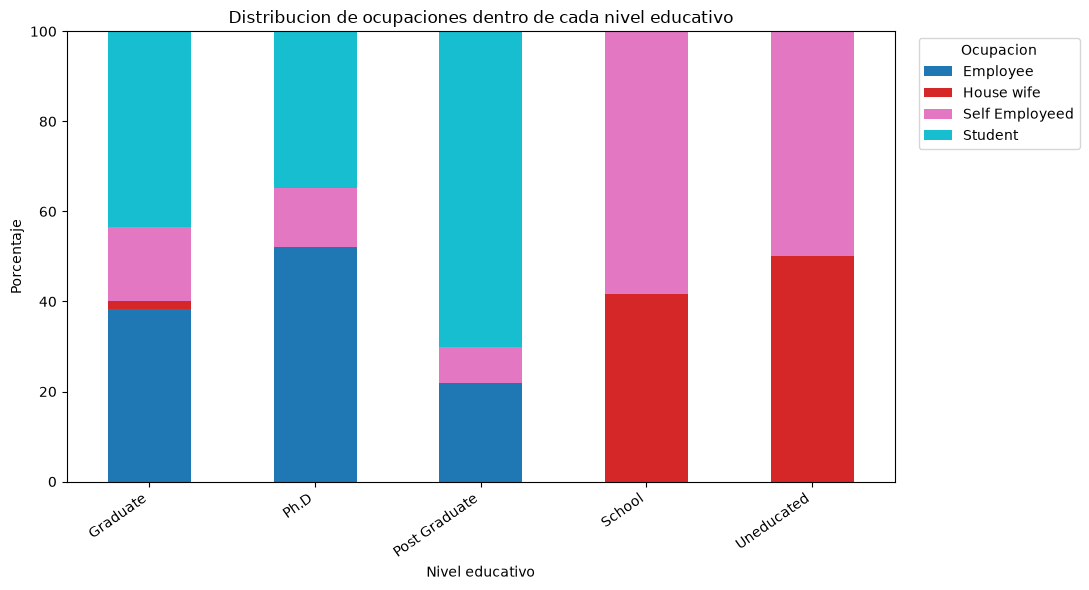

In [5]:
ax = porcentajes.plot(kind='bar', stacked=True, figsize=(11, 6), colormap='tab10')
ax.set_title('Distribucion de ocupaciones dentro de cada nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Porcentaje')
ax.legend(title='Ocupacion', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [6]:
chi2, p_valor, grados_libertad, esperadas = chi2_contingency(tabla)
n = tabla.to_numpy().sum()
filas, columnas = tabla.shape
phi2 = chi2 / n
phi2_corregido = max(0, phi2 - ((columnas - 1) * (filas - 1)) / (n - 1))
filas_corregidas = filas - ((filas - 1) ** 2) / (n - 1)
columnas_corregidas = columnas - ((columnas - 1) ** 2) / (n - 1)
v_cramer = (phi2_corregido / max(1, min(columnas_corregidas - 1, filas_corregidas - 1))) ** 0.5
print(f'Chi-cuadrado: {chi2:.3f} | gl: {grados_libertad} | p-valor: {p_valor:.6g}')
print(f"V de Cramer (corregida): {v_cramer:.3f}")
print('Asociacion estadisticamente significativa (alpha=0.05).' if p_valor < 0.05 else 'No se detecta asociacion estadisticamente significativa (alpha=0.05).')

Chi-cuadrado: 165.653 | gl: 12 | p-valor: 3.69185e-29
V de Cramer (corregida): 0.365
Asociacion estadisticamente significativa (alpha=0.05).


,variable,tipo_analitico,dtype_pandas,categorias_observadas
0,Educational Qualifications,Categórica ordinal,str,"[Graduate, Ph.D, Post Graduate, School, Uneduc..."
1,Occupation,Categórica nominal,str,"[Employee, House wife, Self Employeed, Student]"


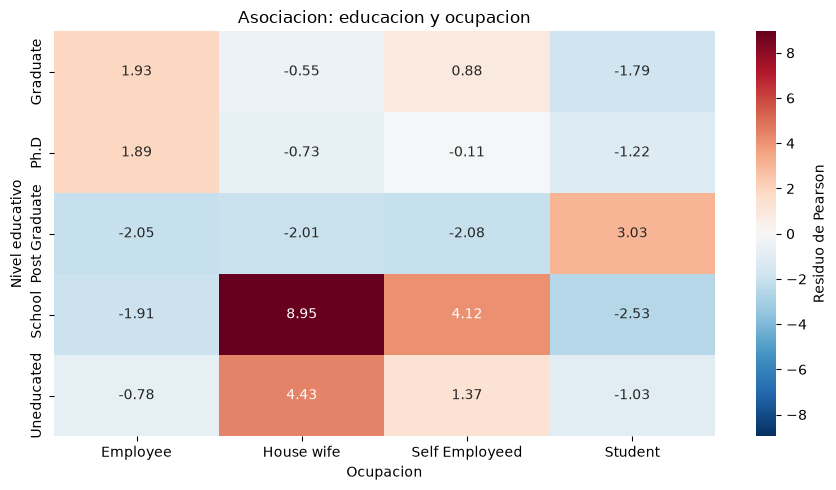

V de Cramer corregida: 0.365
Residuo positivo: combinacion mas frecuente de lo esperado bajo independencia.


In [7]:
import numpy as np
import seaborn as sns

variables = [educacion, ocupacion]
tipos = ["Categórica ordinal", "Categórica nominal"]
resumen_tipos = pd.DataFrame(
    {
        "variable": variables,
        "tipo_analitico": tipos,
        "dtype_pandas": [str(df[variable].dtype) for variable in variables],
        "categorias_observadas": [
            sorted(df[variable].dropna().unique().tolist())
            for variable in variables
        ],
    }
)
display(resumen_tipos)

_, _, _, esperadas_heatmap = chi2_contingency(tabla, correction=False)
residuos_pearson = (tabla - esperadas_heatmap) / np.sqrt(esperadas_heatmap)
limite_color = max(abs(residuos_pearson.to_numpy()).max(), 1)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    residuos_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-limite_color,
    vmax=limite_color,
    cbar_kws={"label": "Residuo de Pearson"},
    ax=ax,
)
ax.set_title("Asociacion: educacion y ocupacion")
ax.set_xlabel("Ocupacion")
ax.set_ylabel("Nivel educativo")
plt.tight_layout()
plt.show()
print(f"V de Cramer corregida: {v_cramer:.3f}")
print("Residuo positivo: combinacion mas frecuente de lo esperado bajo independencia.")